In [1]:
import pandas as pd
import numpy as np
import warnings 
import folium
import koreanize_matplotlib
import glob
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow import keras
warnings.filterwarnings('ignore')

1. Train과 Test로 분류하기
2. CNN 만들기
3. 시각화 (손실)
4. 평가
5. 이미지로 예측하기
   

In [2]:
import glob 

trainfiles = glob.glob('../Data/fingers/train/*.png')
testfiles = glob.glob('../Data/fingers/test/*.png')

In [3]:
train = []
test = []
train_label = []
for i in trainfiles:
    image = Image.open(i)
    imgResize = image.resize((32, 32), Image.Resampling.LANCZOS)
    train.append(imgResize)
    train_label.append(i[-6:-4])

test_label = []
for i in testfiles:
    image = Image.open(i)
    imgResize = image.resize((32, 32), Image.Resampling.LANCZOS)
    test.append(imgResize)
    test_label.append(i[-6:-4])


In [4]:
label_to_int = {
    '0R' : 0,
    '1R' : 1,
    '2R' : 2,
    '3R' : 3,
    '4R' : 4,
    '5R' : 5,
    '0L' : 6,
    '1L' : 7,
    '2L' : 8,
    '3L' : 9,
    '4L' : 10,
    '5L' : 11,
}

In [5]:
temp_data = np.zeros(
    18000*32*32,
    dtype=np.int32
).reshape(18000,32,32)

i = 0
for image in train:
    img = np.array(image, dtype= np.int32)
    temp_data[i,:,:] = img
    i += 1
train_input = temp_data.copy()

In [6]:
temp_data = []
temp_data = np.zeros(
    3600*32*32,
    dtype=np.int32
).reshape(3600,32,32)

i = 0
for image in test:
    img = np.array(image, dtype= np.int32)
    temp_data[i,:,:] = img
    i += 1
test_input = temp_data.copy()

In [7]:
temp = []
for label in train_label:
    temp.append(label_to_int[label])
train_target = temp.copy()    
temp = []
for label in test_label:
    temp.append(label_to_int[label])
test_target = temp.copy()    

In [8]:
train_scaled = train_input.reshape(-1, 32, 32, 1) / 255
test_scaled = test_input.reshape(-1, 32, 32, 1) / 255

In [9]:
train_data, valid_data, train_target, valid_target = train_test_split(
    train_scaled, 
    train_target,
    test_size=0.2,
    random_state=42
) 

In [10]:
print(train_data.shape)
print(np.array(train_target).shape)
print(valid_data.shape)
print(np.array(valid_target).shape)
print(test_input.shape)
print(np.array(test_target).shape)

(14400, 32, 32, 1)
(14400,)
(3600, 32, 32, 1)
(3600,)
(3600, 32, 32)
(3600,)


In [11]:
model = keras.Sequential()

model.add(keras.layers.Conv2D(
    32,
    kernel_size=3,
    activation='relu',
    padding='same',
    input_shape = (32,32,1)
))
model.add(keras.layers.MaxPool2D(2))

In [12]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(12, activation='softmax'))


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       819,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,212 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,832 (3.13 MB)

 Trainable params: 820,832 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    loss = 'sparse_categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy'],
)
checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_model.keras')
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    train_data, 
    np.array(train_target), 
    epochs=20, 
    validation_data=(valid_data, np.array(valid_target)),
    callbacks = [checkpoint_cb, early_stopping_cb]
)

Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7656 - loss: 0.7768 - val_accuracy: 0.9750 - val_loss: 0.0827
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9460 - loss: 0.1780 - val_accuracy: 0.9967 - val_loss: 0.0160
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9654 - loss: 0.1088 - val_accuracy: 0.9972 - val_loss: 0.0108
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9758 - loss: 0.0723 - val_accuracy: 0.9997 - val_loss: 0.0036
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9794 - loss: 0.0627 - val_accuracy: 0.9994 - val_loss: 0.0026
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9832 - loss: 0.0502 - val_accuracy: 0.9992 - val_loss: 0.0034
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9827 - loss: 0.0490 - val_accuracy: 1.0000 - val_loss: 8.4024e-04
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9857 - loss: 0.0400 - val_accuracy

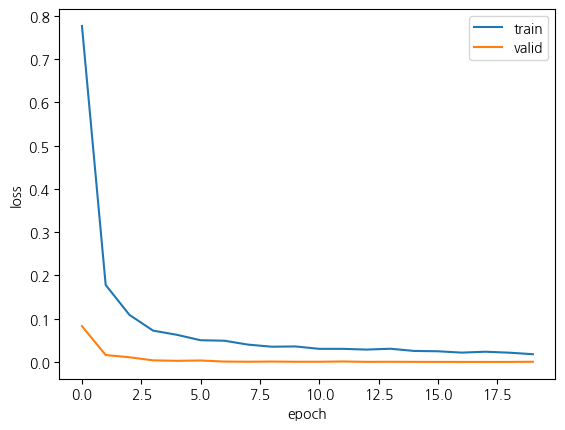

In [15]:
# 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [16]:
model.evaluate(train_data, np.array(train_target))
model.evaluate(valid_data, np.array(valid_target))
model.evaluate(test_scaled, np.array(test_target))


450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 6.4655e-06
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 1.8035e-05
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 7.0175e-05


[7.017486495897174e-05, 1.0]

In [ ]:
img = Image.open('../Data/test.png')
imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)
imgArray = np.array(imgResize)
imgArray = imgArray / 255
imgArray2 = imgArray.reshape(-1)
imgArray3 = imgArray2.tolist()
dfArray = pd.DataFrame(imgArray3)
dfArray = dfArray.T
dfArray
# np.argmax(model.predict(dfArray)))

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 1), dtype=float32) with name 'keras_tensor' and path ''. Expected shape (None, 32, 32, 1), but input has incompatible shape (32, 1)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 1), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [34]:
imgArray2

array([0.16862745, 0.18431373, 0.18039216, ..., 0.16470588, 0.17647059,
       0.17254902], shape=(1024,))